In [41]:
# Importação das bibliotecas
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Etapa 1 - Carregamento e preparação dos dados

In [42]:
# Carregamentos dos dados
geo_0 = pd.read_csv('../data/geo_data_0.csv')
geo_1 = pd.read_csv('../data/geo_data_1.csv')
geo_2 = pd.read_csv('../data/geo_data_2.csv')

In [43]:
# Inspesão dos dados 'tabela 0'
print(geo_0.head())
print()
print(geo_0.info())

      id        f0        f1        f2     product
0  txEyH  0.705745 -0.497823  1.221170  105.280062
1  2acmU  1.334711 -0.340164  4.365080   73.037750
2  409Wp  1.022732  0.151990  1.419926   85.265647
3  iJLyR -0.032172  0.139033  2.978566  168.620776
4  Xdl7t  1.988431  0.155413  4.751769  154.036647

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None


In [44]:
# Inspesão dos dados 'tabela 1' 
print(geo_1.head())
print()
print(geo_1.info())

      id         f0         f1        f2     product
0  kBEdx -15.001348  -8.276000 -0.005876    3.179103
1  62mP7  14.272088  -3.475083  0.999183   26.953261
2  vyE1P   6.263187  -5.948386  5.001160  134.766305
3  KcrkZ -13.081196 -11.506057  4.999415  137.945408
4  AHL4O  12.702195  -8.147433  5.004363  134.766305

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None


In [45]:
# Inspesãodos dados 'tabela 2' 
print(geo_2.head())
print()
print(geo_2.info())

      id        f0        f1        f2     product
0  fwXo0 -1.146987  0.963328 -0.828965   27.758673
1  WJtFt  0.262778  0.269839 -2.530187   56.069697
2  ovLUW  0.194587  0.289035 -5.586433   62.871910
3  q6cA6  2.236060 -0.553760  0.930038  114.572842
4  WPMUX -0.515993  1.716266  5.899011  149.600746

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None


In [46]:
# Checando valores ausentes
def check_missed_values(geo_0, geo_1, geo_2):
    missing_0 = geo_0.isna().sum()
    missing_1 = geo_1.isna().sum()
    missing_2 = geo_2.isna().sum()
    return {'geo_0': missing_0[missing_0 > 0], 
            'geo_1': missing_1[missing_1 > 0], 
            'geo_2': missing_2[missing_2 > 0]} 

check_missed_values(geo_0, geo_1, geo_2)

{'geo_0': Series([], dtype: int64),
 'geo_1': Series([], dtype: int64),
 'geo_2': Series([], dtype: int64)}

In [47]:
# Verificando valores duplicados
def check_duplicates(geo_0, geo_1, geo_2):
    dup_0 = geo_0.duplicated().sum()
    dup_1 = geo_1.duplicated().sum()
    dup_2 = geo_2.duplicated().sum()
    return {'geo_0': dup_0, 'geo_1': dup_1, 'geo_2': dup_2}

check_duplicates(geo_0, geo_1, geo_2)

{'geo_0': np.int64(0), 'geo_1': np.int64(0), 'geo_2': np.int64(0)}

In [48]:
# Verificando o 'dtypes' 
def check_types(geo_0, geo_1,geo_2):
    return {'geo_0': geo_0.dtypes, 
            'geo_1': geo_1.dtypes, 
            'geo_2': geo_2.dtypes}

check_types(geo_0, geo_1,geo_2)

{'geo_0': id          object
 f0         float64
 f1         float64
 f2         float64
 product    float64
 dtype: object,
 'geo_1': id          object
 f0         float64
 f1         float64
 f2         float64
 product    float64
 dtype: object,
 'geo_2': id          object
 f0         float64
 f1         float64
 f2         float64
 product    float64
 dtype: object}

In [49]:
# Separação de features e target
def split_features_target(geo_0, geo_1, geo_2):
    # Selecionar apenas colunas numéricas (excluir colunas não numéricas)
    X_0 = geo_0.drop(columns=['product']).select_dtypes(include=['number'])
    y_0 = geo_0['product']
    X_1 = geo_1.drop(columns=['product']).select_dtypes(include=['number'])
    y_1 = geo_1['product']
    X_2 = geo_2.drop(columns=['product']).select_dtypes(include=['number'])
    y_2 = geo_2['product']
    return X_0, y_0, X_1, y_1, X_2, y_2

# Guardar o retorno em variáveis
X_0, y_0, X_1, y_1, X_2, y_2 = split_features_target(geo_0, geo_1, geo_2)

In [50]:
# Aplicação do 'Scale' para regressão linear
def scale_features(X_train, X_valid):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_valid_scaled = scaler.transform(X_valid)

    return X_train_scaled, X_valid_scaled

### Resumo da etapa 1:
Os dados foram carregados a partir de três arquivos distintos, cada um representando uma região de exploração de petróleo.

Inicialmente, foi realizada uma EDA simples para verificar as **estruturas dos dados**, **tipos de váriaveis**, **presença de valores ausentes**, **duplicatas**

E em seguida verifiquei a ausência de valores nulos, confirmei se todas as variáveis estavam no formato adequado e separei as variáveis independentes(f0,f1,f2)

Por fim, apliquei o **StandardScaler** para padronizar as variáveis, a fim de garantir melhor estabilidade numérica durante o treinamento do modelo de **regressão linear**

# Etapa 2 - Treinamento e Teste do modelo (Regressão linear)

In [51]:
# Divisão treino/validação(75:25)
def split_data(X, y, test_size=0.25, random_state=12):
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

In [52]:
# Treinamento do modelo + predição
def train_predict(X_train, X_valid, y_train):
    
    # Modelo de regressão linear
    model = LinearRegression()
    
    # Treinamento do modelo com os dados de treino
    model.fit(X_train, y_train)
    
    # Gerando predições no conjunto de validação
    predictions = model.predict(X_valid)

    return model, predictions


In [53]:
# Avaliação do modelo
def evaluate_model(y_valid, predictions):
    
    # Calculando o RMSE(raiz do erro quadrático médio)
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    
    # Calculando o volume médio previsto (média das predições)
    avg_predicted = predictions.mean()

    return rmse, avg_predicted

In [54]:
# Conjunto de validação
def run_model(X, y, region_name):
    
    # Divisão treino/validação
    X_train, X_valid, y_train, y_valid = split_data(X, y)
    
    # Escalonamento 
    scaler = StandardScaler()
    
    # Ajuste no treino e transforma treino e validação
    X_train_scaled = scaler.fit_transform(X_train)
    X_valid_scaled = scaler.transform(X_valid)
    
    # Treinamento + predição
    model, predictions = train_predict(X_train_scaled, X_valid_scaled, y_train)

    # Avaliação do modelo
    rmse, avg_predicted = evaluate_model(y_valid, predictions)

    # Exibição dos resultados
    print(f'Região: {region_name}')
    print(f'Volume médio previsto: {avg_predicted:.2f}')
    print(f'REQM: {rmse:.2f}')

    return {'model': model,
            'predictions': predictions,
            'y_valid': y_valid,
            'rmse': rmse,
            'avg_predicted': avg_predicted}

In [55]:
# Analise dos resultados
# Executando cada região
results_0 = run_model(X_0, y_0, 'Região 0')
results_1 = run_model(X_1, y_1, 'Região 1')
results_2 = run_model(X_2, y_2, 'Região 2')

Região: Região 0
Volume médio previsto: 92.13
REQM: 37.79
Região: Região 1
Volume médio previsto: 69.04
REQM: 0.89
Região: Região 2
Volume médio previsto: 95.05
REQM: 39.80


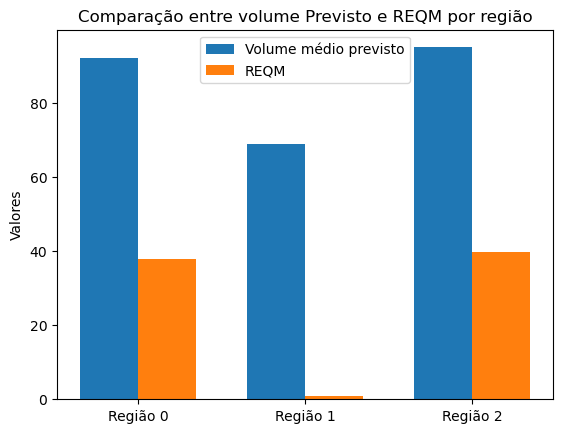

In [56]:
# Gráfico comparando o Volume médio X REQM
def plot_model_results(results_0, results_1, results_2):
    regions = ['Região 0', 'Região 1', 'Região 2']

    # Extraindo as métricas
    avg_predictions = [results_0['avg_predicted'],
                       results_1['avg_predicted'],
                       results_2['avg_predicted']]
    
    rmse = [results_0['rmse'],
            results_1['rmse'],
            results_2['rmse']]
    
    # Posição das barras
    x = np.arange(len(regions))
    width = 0.35 #largura das barras

    plt.Figure()

    # Barras do volume médio
    plt.bar(x - width/2, avg_predictions, width, label='Volume médio previsto')

    # Barras de RMSE
    plt.bar(x + width/2, rmse, width, label='REQM')

    plt.xticks(x, regions)
    plt.ylabel('Valores')
    plt.title('Comparação entre volume Previsto e REQM por região')
    plt.legend()

    plt.show()

plot_model_results(results_0, results_1, results_2)

### Resumo etapa 2:

Os modelos de regressão linear foram treinados para cada região com divisão 75:25 entre treino e teste, e foram avaliadas duas métricas principais: **Volume médio previsto**, oque indica potencial produtivo, e **REQM**, que mede o erro das previsões

**Observações:**
As regiões com maior volume médio podem indicar maior potencial de lucro
As regiões com menor REQM apresentam previsões mais confiáveis

**A decisão final não deve ser tomada apenas com base nesses resultados, pois o lucro real depende da seleção dos melhores poços e da análise de risco via bootstrapping**.

# Etapa 3 - Cálculo de lucro

In [57]:
# Armazenamento das variáveis de negócio
# Investimento total para 200 poços
budget = 100_000_000 #100 milhões de dólares

# Número de poços selecionados
n_wells = 200

# Receita gerada por unidade de produto(milhares de barris)
revenue_per_unit = 4500 # dólares por unidade

# Cálculos financeiros
# Custo médio por poço
cost_per_well = budget/ n_wells

# volume mínimo necessário por poço para atingir o break-even(Ponto de equilibrio)
# Fórmula: custo / receita por unidade
break_even_volume = cost_per_well / revenue_per_unit

print(f'Custo médio por poço: {cost_per_well:.2f}')
print(f'Volue mínimo por poço (Ponto de equilibrio): {break_even_volume:.2f}')

Custo médio por poço: 500000.00
Volue mínimo por poço (Ponto de equilibrio): 111.11


In [58]:
# Comparação com o volume médio previsto
def compare_break_even(results, region_name, break_even):
    
    # Extraindo o volume médio previsto do modelo
    avg_volume = results['avg_predicted']

    print(f'Region {region_name}')
    print(f'Volume médio previsto: {avg_volume:.2f}')
    print(f'Break even: {break_even:.2f}')

    # Avalia se a região supera o ponto de equilibrio
    if avg_volume > break_even:
        print('Região potencialmente lucrativa')
    
    else:
        print('Região não é potencialmente lucrativa')

# Executando para cada região
compare_break_even(results_0, 'Região 0', break_even_volume)
compare_break_even(results_1, 'Região 1', break_even_volume)
compare_break_even(results_2, 'Região 2', break_even_volume)

Region Região 0
Volume médio previsto: 92.13
Break even: 111.11
Região não é potencialmente lucrativa
Region Região 1
Volume médio previsto: 69.04
Break even: 111.11
Região não é potencialmente lucrativa
Region Região 2
Volume médio previsto: 95.05
Break even: 111.11
Região não é potencialmente lucrativa


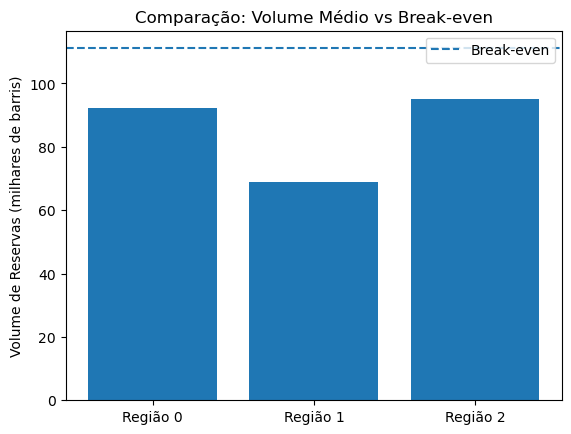

In [59]:
def plot_break_even_comparison(results_0, results_1, results_2, break_even):

    # Nome das regiões
    regions = ['Região 0', 'Região 1', 'Região 2']
    
    # Extraindo volume médio previsto de cada região
    avg_volumes = [
        results_0['avg_predicted'],
        results_1['avg_predicted'],
        results_2['avg_predicted']]
    
    plt.figure()
    
    # Cria gráfico de barras com os volumes médios
    plt.bar(regions, avg_volumes)
    
    # Adiciona linha horizontal representando o break-even
    plt.axhline(y=break_even, linestyle='--', label='Break-even')
    
    plt.title('Comparação: Volume Médio vs Break-even')
    plt.ylabel('Volume de Reservas (milhares de barris)')
    plt.legend()
    plt.show()

plot_break_even_comparison(results_0, results_1, results_2, break_even_volume)

### Resumo da Etapa 3:

O orçamento disponivel total para o desenvolvimento dos poços é de 100 milhões de dólares, distribuidos entre 200 poços, resultando em um custo médio de 500 mil dólares por poço

Considerando que cada unidade de produto gera 4.500 dólares, o volume necessário para atingir o ponto de equlibrio é de aproximadamente 111.1 unidades por poço

A comparação entre esse valor e o volume médio previsto de cada região permite uma análise inicial, **regiões acima do break even indicam potencial de lucratividade**, e **regiões abaixo indicam maior risco de prejuizo**

Porém, essa análise ainda está limitada, pois, está utlizando **média gerais**, não considera a seleção dos melhores poços e também não avalia a variabilidade e risco

# Etapa 4: Encontrando os Melhores poços

In [60]:
# Função para selecionar os 200 melhore poços
def select_top_wells(predictions, y_valid, n_wells=200):

    # cria um DataFrame combinando predição e valor real
    data = pd.DataFrame({'predictions': predictions,
                         'target': y_valid})
    
    # Ordena pelos maiores valores previstos
    top_wells = data.sort_values(by='predictions', ascending=False)

    # Seleciona os melhore poços
    top_wells = top_wells.head(n_wells)

    return top_wells

In [61]:
# Função para cálcular o lucro
def calculate_profit(top_wells, revenue_per_unit, budget):

    # Soma do volume real dos poços selecionados
    total_volume = top_wells['target'].sum()

    # Receita total
    total_revenue = total_volume * revenue_per_unit

    # Lucro = receita - investimento
    profit = total_revenue - budget

    return profit, total_volume

In [62]:
# Função para análise completa das regiões
def analyze_region(results, region_name, revenue_per_unit, budget):

    # Seleciona os melhores poços
    top_wells = select_top_wells(results['predictions'], results['y_valid'])

    # Calcula o lucro
    profit, total_volume = calculate_profit(top_wells, revenue_per_unit, budget)

    print(f'Região: {region_name}')
    print(f'Volume total (top 200): {total_volume:.2f}')
    print(f'Lucro estimado: ${profit:,.2f}')

    return {'profit': profit,
            'total_volume': total_volume,
            'top_wells': top_wells}

In [63]:
# Exibindo os resultados
profit_0 = analyze_region(results_0, 'Região 0', revenue_per_unit, budget)
profit_1 = analyze_region(results_1, 'Região 1', revenue_per_unit, budget)
profit_2 = analyze_region(results_2, 'Região 2', revenue_per_unit, budget)

Região: Região 0
Volume total (top 200): 29819.18
Lucro estimado: $34,186,319.61
Região: Região 1
Volume total (top 200): 27589.08
Lucro estimado: $24,150,866.97
Região: Região 2
Volume total (top 200): 27888.78
Lucro estimado: $25,499,492.02


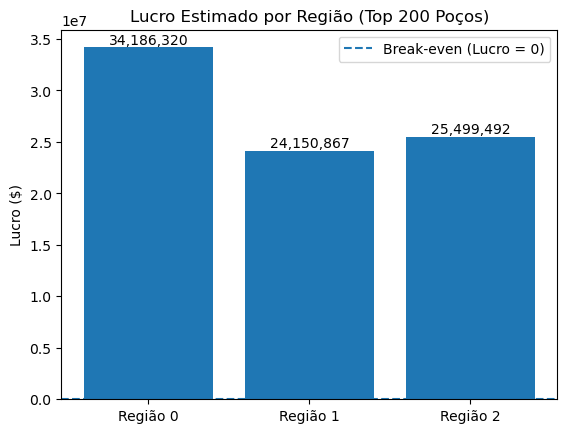

In [ ]:
# Gráfico para melhor visualização
def plot_profit_comparison(profit_0, profit_1, profit_2):
    
    # Nome das regiões
    regions = ['Região 0', 'Região 1', 'Região 2']
    
    # Extraindo lucros
    profits = [profit_0['profit'],
               profit_1['profit'],
               profit_2['profit']]
    
    plt.figure()
    
    # Cria gráfico de barras com os lucros
    bars = plt.bar(regions, profits)
    
    # Adiciona linha horizontal em zero (ponto de prejuízo)
    plt.axhline(y=0, linestyle='--', label='Break-even (Lucro = 0)')
    
    # Exibe o valor do lucro acima de cada barra
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,  # posição x
            height,                              # posição y
            f'{height:,.0f}',                    # texto formatado
            ha='center',                         # alinhamento horizontal
            va='bottom'                          # alinhamento vertical
        )
    
    plt.title('Lucro Estimado por Região (Top 200 Poços)')
    plt.ylabel('Lucro ($)')
    plt.legend()
    plt.show()

plot_profit_comparison(profit_0, profit_1, profit_2)

### Resumo da Etapa 4:

Após selecionar os 200 poços com maior volume previsto, foi calculado o lucro com base nos valores reais de produção

**Observações:**
A seleção dos melhores poços altera completamente a análise em relação a média geral, as regiões que não atingiam o brek even (**Ponto de equilibrio**) na média agora podem apresentar lucro significativo e o modelo se mostra útil na priorização de poços mais produtivos

A região mais indicada para desenvolvimento é aquela que apresentou: **Maior lucro total** e **um volume consistente nos melhores poços**

### Etapa 5: Bootstrapping (Risco e Lucro)

In [67]:
# Aplicação do bootstrapping para estimar a distribuição dos lucros
def bootstrap_profit(predictions, y_valid, revenue_per_unit, budget, n_samples=1000, n_wells=200):

    profits = []

    # Loop de amostragem
    for i in range(n_samples):

        # Amostragem com reposição
        indices = np.random.choice(len(predictions), size=500, replace=True)

        sampled_preds = predictions[indices]
        sampled_target = y_valid.iloc[indices]

        # Seleção dos melhores poços
        data = np.array(list(zip(sampled_preds, sampled_target)))

        # Ordenação pela predição (coluna 0)
        data = data[data[:, 0].argsort()[::-1]]

        # Seleciona os números melhores de poços
        top_wells = data[:n_wells]

        # Calculo do lucro
        total_volume = top_wells[:, 1].sum()
        revenue = total_volume * revenue_per_unit
        profit = revenue - budget

        profits.append(profit)

    return profits 



In [ ]:
# Função para métricas de risco
def analyze_bootstrap(profits):

    profits = np.array(profits)

    # Lucro médio
    mean_profit = profits.mean()

    # Intervalo de confiança de 95%
    lower = np.percentile(profits, 2.5)
    upper = np.percentile(profits, 97.5)

    # Risco de prejuizo (Lucro < 0)
    risk = (profits < 0).mean() * 100 # Porcentagem

    return mean_profit, lower, upper, risk

In [70]:
# Aplicação para cada região
# Região 0
profits_0 = bootstrap_profit(results_0['predictions'], results_0['y_valid'], revenue_per_unit, budget)
analyze_0 = analyze_bootstrap(profits_0)

# Região 1
profits_1 = bootstrap_profit(results_1['predictions'], results_1['y_valid'], revenue_per_unit, budget)
analyze_1 = analyze_bootstrap(profits_1)

# Região 2
profits_2 = bootstrap_profit(results_2['predictions'], results_2['y_valid'], revenue_per_unit, budget)
analyze_2 = analyze_bootstrap(profits_2)

In [71]:
# Exibição dos resultados
def print_bootstrap_results(analyze, region_name):
    
    mean, lower, upper, risk = analyze

    print(f'Region: {region_name}')
    print(f'Lucro médio: ${mean:,.2f}')
    print(f'Intervalo de confiança: {lower:,.2f}, {upper:,.2f}')
    print(f'risco de prejuizo: {risk:.2f}%')

print_bootstrap_results(analyze_0, 'Região 0')
print_bootstrap_results(analyze_1, 'Região 1')
print_bootstrap_results(analyze_2, 'Região 2')

Region: Região 0
Lucro médio: $4,439,982.89
Intervalo de confiança: -1,084,056.33, 9,670,268.27
risco de prejuizo: 4.90%
Region: Região 1
Lucro médio: $4,927,390.89
Intervalo de confiança: 1,010,041.04, 9,022,188.15
risco de prejuizo: 0.80%
Region: Região 2
Lucro médio: $3,414,131.99
Intervalo de confiança: -1,981,996.52, 9,004,695.18
risco de prejuizo: 10.40%


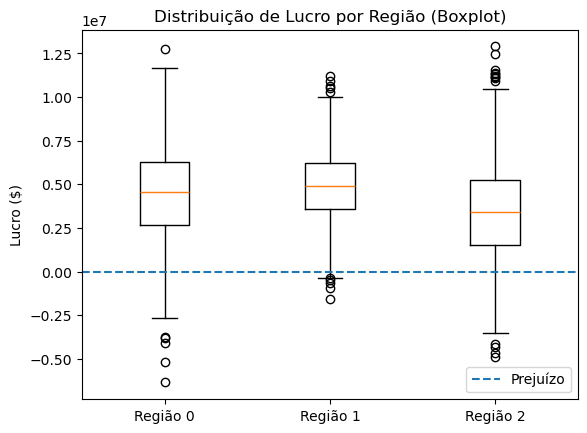

In [83]:
# Boxplot para melhor visualização dos resultados
def plot_boxplot(profits_0, profits_1, profits_2):
    
    plt.figure()
    plt.boxplot(
        [profits_0, profits_1, profits_2],
        tick_labels=['Região 0', 'Região 1', 'Região 2']
    )
    
    # Linha de prejuízo
    plt.axhline(0, linestyle='--', label='Prejuízo')
    
    plt.title('Distribuição de Lucro por Região (Boxplot)')
    plt.ylabel('Lucro ($)')
    plt.legend()
    plt.show()
    
plot_boxplot(profits_0, profits_1, profits_2)

### Resumo da Etapa 5:
Com base na análise do bootstrapping realizada para as três regiões, foi possível avaliar não apenas o lucro esperado, mas também a variabilidade dos resultados e o risco associado a cada decisão de investimento

A **Região 0** apresentou um **lucro médio** de aproximadamente (**4,44 milhões**), porém seu intervalo de confiança inclui valores negativos e o **risco de prejuizo** é de (**4,90%**), ultrapassando o **limite aceitável** de (**2,5%**), o que a torna uma opção insegura

A **Região 2**, por sua vez, apresentou o **menor lucro médio** entre as três (**3,41 milhões**), além de um **risco ainda mais elevado**, de **10,40%**, também com intervalo de confiança cruzando o zero, reforçando sua inviabilidade

A **Região 1** se destacou por apresentar o **maior lucro médio** (**4,93 milhões**), um intervalo de confiança totalmente acima do zero, indicando consistência nos resultados, o **risco de prejuizo** foi de apenas **0,80%**, significativamente abaixo do limite estabelecido

Essa leitura é reforçada pela **análise do boxplot**, que permite visualizar a distribuição dos lucro simulados de forma mais intuitiva, No **boxplot da região 1**, a caixa (**que representa os 50% centrais dos resultados**) encontra-se completamente acima da linha de prejuizo, indicando que a maior parte dos cenários simulados gera lucro, e além disso, a mediana está posicionada em um nível elevado, mostrando que o resultado típico da região é positivo e consistente

Em contraste, nas **regiões 0 e 2**, parte da caixa ou dos **bigodes** cruza a linha de zero, evidenciando a presença relevante de cenários com prejuizo. A maior dispersão observada nessas regiões também indica maior instabilidade nos resultados, aumentando o risco da operação

Portanto, conclui-se que a **região 1** é a escolha mais adequada para o desenvolvimento de novos poços de petróleo, pois oferece a melhor combinação entre retorno financeiro e segurança. Essa decisão confirma a análise anterior baseada no lucro dos melhores poços, mas agora com a validação estatistica mais robusta, evidenciando a importância de considerar a distribuição dos resultados e o risco na tomada de decisões.
